In [1]:
import math
import torch
from torch import nn
from d2l import torch as d2l


def masked_softmax(X: torch.Tensor, valid_lens):
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            # 也就是valid_lens=(batch_size,),所以一个batch里的shape[1]个query是同一个长度
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            # (batch_size,query)已经给每个query都设定好长度了,直接展开就可以了
            valid_lens = valid_lens.reshape(-1)
        # reshape成每个query排开，然后做掩码，把有效长度外的值都设为-1e6，因为做softmax时每个元素x的权值是exp(x),
        # 所以设成-1e6可以使softmax时把有效长度外的元素忽略掉，也就是它们的值变为0
        X = d2l.sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=int(-1e6))
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [ ]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.2567, 0.2663, 0.4769, 0.0000]],

        [[0.5762, 0.4238, 0.0000, 0.0000],
         [0.2883, 0.3727, 0.1627, 0.1763]]])

In [ ]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.2391, 0.3657, 0.3952, 0.0000]],

        [[0.5251, 0.4749, 0.0000, 0.0000],
         [0.3087, 0.3424, 0.1793, 0.1696]]])

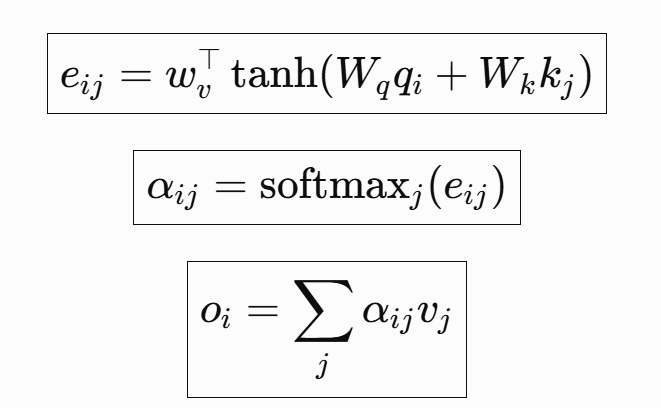

In [7]:
# 加性注意力
class AdditiveAttention(nn.Module):
    def __init__(self, key_size, query_size, num_hiddedns, dropout):
        super().__init__()
        self.W_k = nn.Linear(key_size, num_hiddedns, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddedns, bias=False)
        self.w_v = nn.Linear(num_hiddedns, 1, bias=False)
        # 每次随机置0一些元素，参数p是每个元素被置0的概率，其它没置0的元素x变为x/(1-p),
        # 可以使训练时输出的期望大小和测试时差不多
        # 是一种防止过拟合的正则化方法，让它不会过度依赖某几个数据，必须学到更分散、更鲁棒的特征
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries: torch.Tensor, keys: torch.Tensor, values, valid_lens):
        # 最初传入的q,k维度分别维(batch_size,num_queries,query_size),(batch_size,num_keys,key_size),先把它们最后一维统一转化为h
        queries, keys = self.W_q(queries), self.W_k(keys)
        # q变为(batch_size,num_q,1,h),k变为(batch_size,1,num_k,h),做广播运算，最后得到的tensor是所有q和所有k两两对应运算的结果
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # squeeze:把长度为1的一维删掉
        scores = self.w_v(features).squeeze(
            -1
        )  # 转为(batch_size,num,q,num_k)也就是所有q,k对，行是q，列是k
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [ ]:
queries, keys = torch.normal(0, 1, (2, 1, 20)), torch.ones((2, 10, 2))
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1)
valid_lens = torch.tensor([2, 6])
attention = AdditiveAttention(key_size=2, query_size=20, num_hiddedns=8, dropout=0.1)
attention.eval()
(attention(queries, keys, values, valid_lens)).shape

torch.Size([2, 1, 4])

$$
\operatorname{Attention}(Q,K,V)
=
\operatorname{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)V
$$

In [ ]:
# 缩放点积注意力
# 要求Q和K的宽一样
class DotProductAttention(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # softmax是指数形式，所以这样整体除以一个相同数会影响最终比例的，这样做的目的就是防止太大的数直接变为1
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)